In [1]:
import urllib.request
import os
import pandas as pd
import numpy as np

Завантаження даних

In [2]:
def download_data():
    folder = 'horses_data'
    os.makedirs(folder, exist_ok=True)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/horse-colic/horse-colic.data"
    file_path = os.path.join(folder, "horse-colic.csv")
    if not os.path.exists(file_path):
        urllib.request.urlretrieve(url, file_path)
        print("all done")
    else:
        print("file exists")
    
    column_names = [
        'surgery', 'age', 'hospital_number', 'rectal_temperature', 'pulse',
        'respiratory_rate', 'temperature_of_extremities', 'peripheral_pulse',
        'mucous_membranes', 'capillary_refill_time', 'pain', 'peristalsis',
        'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux',
        'nasogastric_reflux_ph', 'rectal_examination', 'abdomen',
        'packed_cell_volume', 'total_protein', 'abdominocentesis_appearance',
        'abdomcentesis_total_protein', 'outcome', 'surgical_lesion',
        'lesion_1', 'lesion_2', 'lesion_3', 'cp_data'
    ]
    df = pd.read_csv(file_path, sep='\s+', names=column_names, usecols=range(len(column_names)), na_values='?')
    return df

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\chern\AppData\Local\Temp\ipykernel_4868\3196366200.py:22: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', names=column_names, usecols=range(len(column_names)), na_values='?')


In [3]:
df = download_data()
display (df.head(15))

file exists


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdomcentesis_total_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2
5,2.0,1,528355,NaN,NaN,NaN,2.0,1.0,3.0,1.0,...,NaN,NaN,NaN,NaN,1.0,2,0,0,0,2
6,1.0,1,526802,37.9,48.0,16.0,1.0,1.0,1.0,1.0,...,37.0,7.0,NaN,NaN,1.0,1,3124,0,0,2
7,1.0,1,529607,NaN,60.0,NaN,3.0,NaN,NaN,1.0,...,44.0,8.3,NaN,NaN,2.0,1,2208,0,0,2
8,2.0,1,530051,NaN,80.0,36.0,3.0,4.0,3.0,1.0,...,38.0,6.2,NaN,NaN,3.0,1,3205,0,0,2
9,2.0,9,5299629,38.3,90.0,NaN,1.0,NaN,1.0,1.0,...,40.0,6.2,1.0,2.2,1.0,2,0,0,0,1


Data Cleaning

In [4]:
def clean_data(df):
    df_clean = df.copy()
    
    df_clean['age'] = df_clean['age'].replace(9, 2)
    
    cols_to_drop = [
        'hospital_number', 
        'nasogastric_reflux_ph', 
        'abdomcentesis_total_protein', 
        'abdominocentesis_appearance'
    ]
    df_clean = df_clean.drop(columns=cols_to_drop)
    
    numeric_cols = ['rectal_temperature', 'pulse', 'respiratory_rate', 'packed_cell_volume', 'total_protein']
    categorical_cols = df_clean.columns.difference(numeric_cols)
    
    for col in numeric_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        
    for col in categorical_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        
    df_clean['surgery'] = df_clean['surgery'].replace(2, 0)
    
    cols_to_int = [
        'surgery', 'pulse', 'respiratory_rate', 
        'outcome', 'age'
    ]

    for col in cols_to_int:
        df_clean[col] = df_clean[col].astype(int)

    return df_clean


In [5]:
df_cleaned = clean_data(df)
display (df_cleaned.head(15))

,surgery,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,...,rectal_examination,abdomen,packed_cell_volume,total_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,0,1,38.5,66,28,3.0,3.0,1.0,2.0,5.0,...,3.0,5.0,45.0,8.4,2,2,11300,0,0,2
1,1,1,39.2,88,20,3.0,1.0,4.0,1.0,3.0,...,4.0,2.0,50.0,85.0,3,2,2208,0,0,2
2,0,1,38.3,40,24,1.0,1.0,3.0,1.0,3.0,...,1.0,1.0,33.0,6.7,1,2,0,0,0,1
3,1,2,39.1,164,84,4.0,1.0,6.0,2.0,2.0,...,3.0,5.0,48.0,7.2,2,1,2208,0,0,1
4,0,1,37.3,104,35,3.0,1.0,6.0,2.0,3.0,...,4.0,5.0,74.0,7.4,2,2,4300,0,0,2
5,0,1,38.2,64,24,2.0,1.0,3.0,1.0,2.0,...,3.0,3.0,45.0,7.5,1,2,0,0,0,2
6,1,1,37.9,48,16,1.0,1.0,1.0,1.0,3.0,...,3.0,5.0,37.0,7.0,1,1,3124,0,0,2
7,1,1,38.2,60,24,3.0,1.0,1.0,1.0,3.0,...,3.0,4.0,44.0,8.3,2,1,2208,0,0,2
8,0,1,38.2,80,36,3.0,4.0,3.0,1.0,4.0,...,3.0,5.0,38.0,6.2,3,1,3205,0,0,2
9,0,2,38.3,90,24,1.0,1.0,1.0,1.0,5.0,...,3.0,5.0,40.0,6.2,1,2,0,0,0,1


Графік залежності атрибуту rectal_temperature від атрибуту pain

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
def plot_temperature_by_pain(df_cleaned):
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(data=df_cleaned, x='pain', y='rectal_temperature')
    
    plt.title('Розподіл ректальної температури залежно від рівня болю', fontsize=14)
    plt.xlabel('Рівень болю (1 - відсутній, 5 - сильний безперервний)', fontsize=12)
    plt.ylabel('Ректальна температура (°C)', fontsize=12)
    
    plt.show()

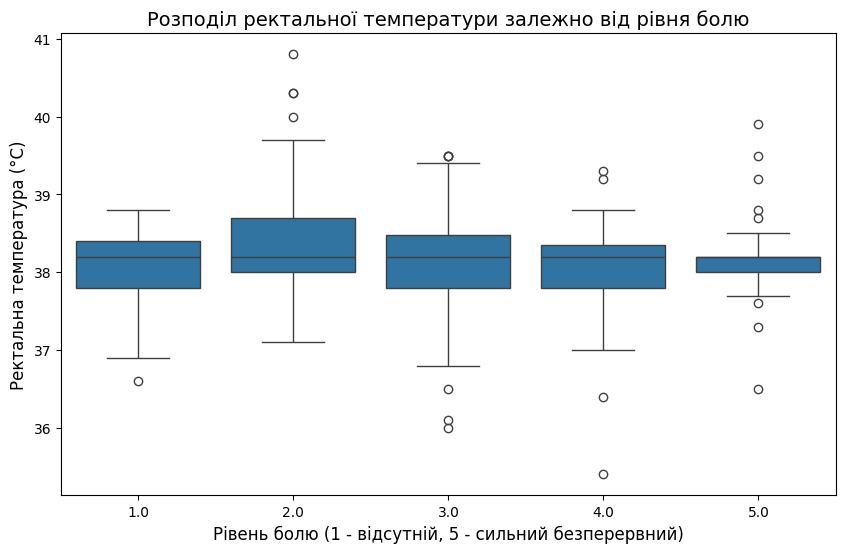

In [8]:
plot_temperature_by_pain(df_cleaned)

Гістограма розподілу атрибуту pulse по 5 діапазонах

In [9]:
def pulse_diagram(df_cleaned):
    plt.figure(figsize=(10, 6))
    
    sns.histplot(data = df_cleaned, x='pulse', edgecolor='black', bins = [30, 60, 90, 120, 150, 180])
    
    plt.title('Діаграма розподілу пульсу по 5 діапазонах', fontsize = 14)
    plt.xlabel('пульс', fontsize = 12)
    plt.ylabel('кількість коней', fontsize = 12)
    
    plt.xticks([30, 60, 90, 120, 150, 180])
    
    plt.show()

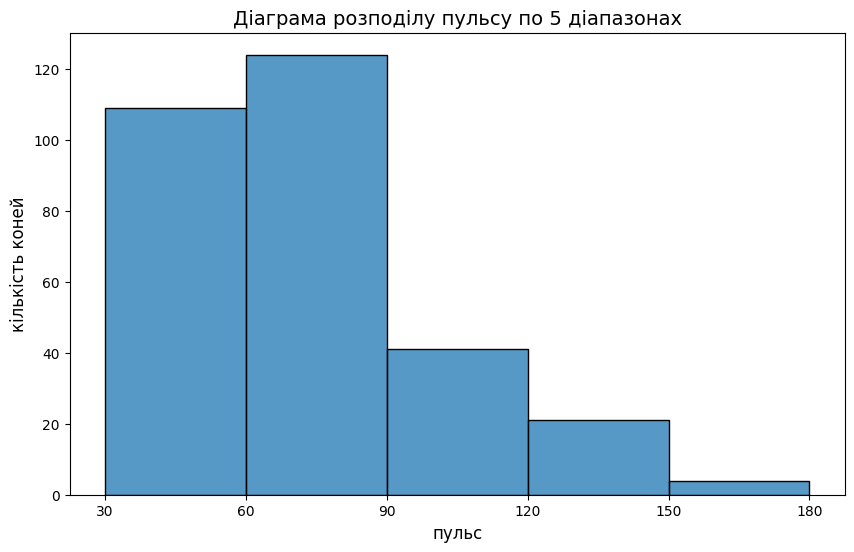

In [11]:
pulse_diagram(df_cleaned)

3d scatter для показників pulse, respiratory rate, rectal temperature

In [12]:
def plot_3d_vitals_scatter(df_cleaned):
    fig = plt.figure(figsize=(10, 6))

    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df_cleaned['pulse'], df_cleaned['respiratory_rate'], df_cleaned['rectal_temperature'])
    ax.set_xlabel('пульс')
    ax.set_ylabel('частота дихання')
    ax.set_zlabel('температура', labelpad=100)
    plt.tight_layout()

    ax.view_init(elev=20, azim=45)
    plt.show()

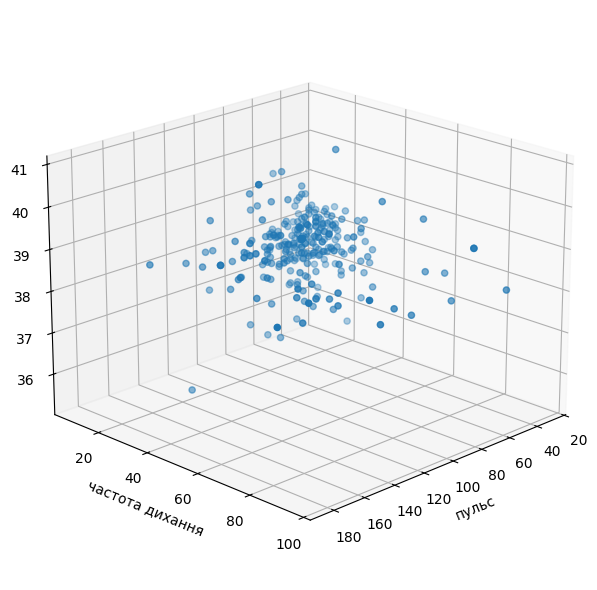

In [13]:
plot_3d_vitals_scatter(df_cleaned)

Heatmap корреляцій між усіма атрибутами

In [14]:
def plot_correlation_heatmap(df_cleaned):
    plt.figure(figsize=(14, 10))
    
    corr_matrix = df_cleaned.corr(numeric_only=True)
    
    sns.heatmap(corr_matrix,
                annot=True,    
                cmap='coolwarm',
                fmt='.2f',
                linewidths=0.5,
                vmin=-1, vmax=1)
    
    plt.title('Теплова карта кореляції між усіма атрибутами', fontsize=16)

    plt.tight_layout()
    
    plt.show()

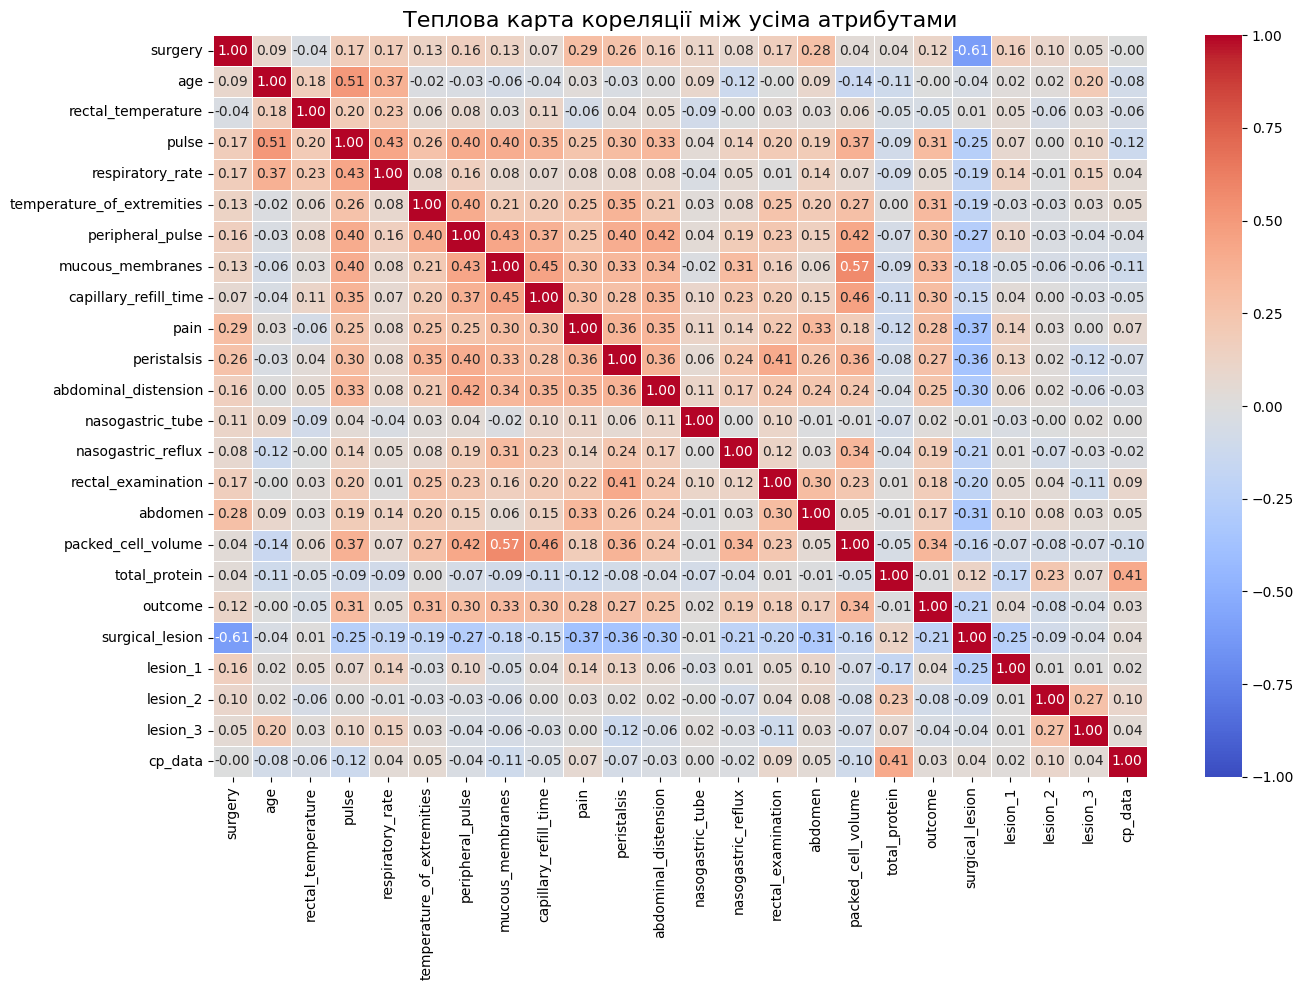

In [15]:
plot_correlation_heatmap(df_cleaned)

кругова діаграма статистики виживання

In [16]:
def plot_outcome_pie_chart(df_cleaned):
    plt.figure(figsize=(8, 8))
    
    outcome_counts = df_cleaned['outcome'].value_counts().sort_index()
    
    labels = ['Вижили', 'Померли', 'Приспані']
    colors = ['#66b3ff', '#ff9999', '#d9d9d9']
    
    plt.pie(outcome_counts, 
            labels=labels, 
            colors=colors, 
            autopct='%1.1f%%',
            startangle=140,
            textprops={'fontsize': 12}, 
            wedgeprops={'edgecolor': 'black', 'linewidth': 1})
    
    plt.title('Загальна статистика результатів лікування (Outcome)', fontsize=16, pad=20)
    
    plt.show()

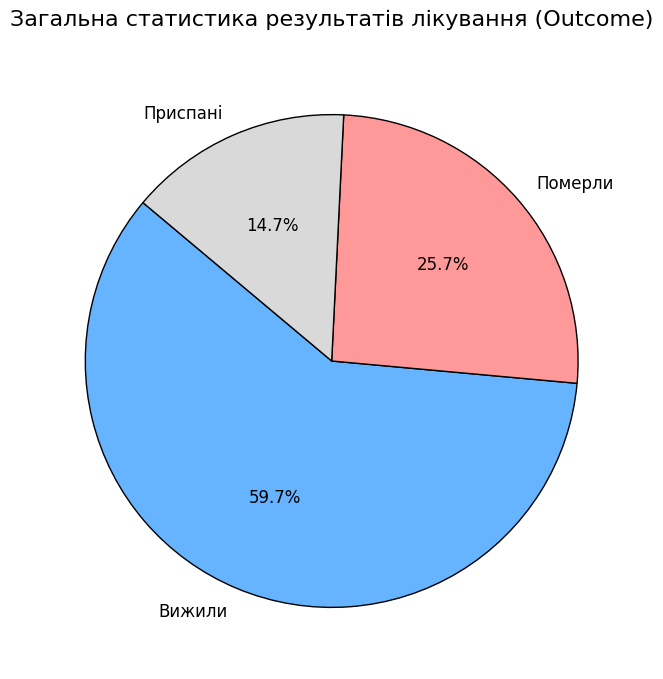

In [17]:
plot_outcome_pie_chart(df_cleaned)